In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv3D,Flatten,BatchNormalization

In [3]:
from tensorflow.keras.datasets import cifar10

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
print(f"X_train shape is : {x_train.shape} {"\n"} x_test shape is : {x_test.shape} {"\n"} y_train shape is :{y_train.shape} {"\n"} y_test shape is : {y_test.shape}")

X_train shape is : (50000, 32, 32, 3) 
 x_test shape is : (10000, 32, 32, 3) 
 y_train shape is :(50000, 1) 
 y_test shape is : (10000, 1)


In [6]:
y_train = y_train.reshape(-1,)
y_train

array([6, 9, 9, ..., 9, 1, 1], dtype=uint8)

In [7]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [8]:
def plot_sample(x_train,y_trian,index):
  plt.figure(figsize=(15,2))
  plt.imshow(x_train[index])
  plt.xlabel(classes[y_train[index]])
  plt.show()

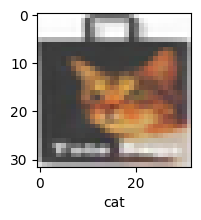

In [9]:
plot_sample(x_train,y_train,3000)

In [10]:
x_train = x_train / 255
x_test = x_test / 255

In [11]:
from tensorflow.keras.layers import *

In [12]:
from tensorflow.keras import regularizers

model1 = Sequential()

model1.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation="relu",
    kernel_regularizer=regularizers.l2(0.00005),
    input_shape=(32,32,3)
))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size=(2,2)))
model1.add(Dropout(0.2))


model1.add(Conv2D(
    filters=42,
    kernel_size=(3,3),
    activation="relu",
    kernel_regularizer=regularizers.l2(0.00005)
))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size=(2,2)))
model1.add(Dropout(0.2))

model1.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation="relu",
    kernel_regularizer=regularizers.l2(0.00005)
))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size=(2,2)))
model1.add(Dropout(0.2))

model1.add(Flatten())


model1.add(Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.00005)
))
model1.add(BatchNormalization())

model1.add(Dropout(0.4))
model1.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 42)     │        12,138 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 42)     │           168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 42)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 42)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        24,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,196 (215.61 KB)

 Trainable params: 54,792 (214.03 KB)

 Non-trainable params: 404 (1.58 KB)

In [14]:
model1.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

In [15]:
history1 = model1.fit(x_train,y_train,epochs=69,validation_data=(x_test,y_test))

Epoch 1/70
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.3838 - loss: 1.7582 - val_accuracy: 0.4850 - val_loss: 1.4385
Epoch 2/70
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5178 - loss: 1.3623 - val_accuracy: 0.5503 - val_loss: 1.2813
Epoch 3/70
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5692 - loss: 1.2355 - val_accuracy: 0.4633 - val_loss: 1.6383
Epoch 4/70
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5989 - loss: 1.1575 - val_accuracy: 0.6095 - val_loss: 1.1336
Epoch 5/70
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6222 - loss: 1.1058 - val_accuracy: 0.5729 - val_loss: 1.2419
Epoch 6/70
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6350 - loss: 1.0716 - val_accuracy: 0.6438 - val_loss: 1.0542
Epoch 7/70
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6430 - loss: 1.0487 - val_accuracy: 0.6397 - val_loss: 1.0291
Epoch 8/70
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6561 - loss: 1.0191

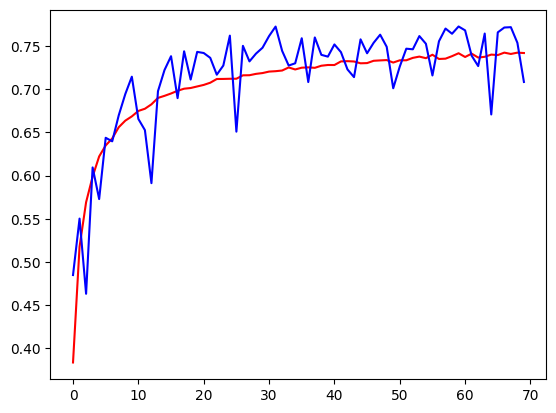

In [16]:
plt.plot(history1.history["accuracy"],color = "red",label = 'accuracy')
plt.plot(history1.history["val_accuracy"],color = "blue",label = 'val_accuracy')
plt.show()

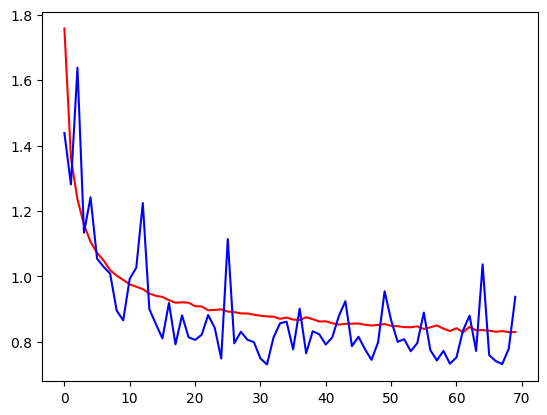

In [17]:
plt.plot(history1.history["loss"],color = "red",label = 'accuracy')
plt.plot(history1.history["val_loss"],color = "blue",label = 'val_accuracy')
plt.show()

In [18]:
y_pred = model1.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [19]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[3]

np.int64(0)

In [20]:
y_test

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

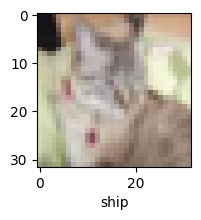

In [21]:
plot_sample(x_test,y_test,8)